---

# ASSIGNMENT 1: SUBPLOTS

---

>---
>
>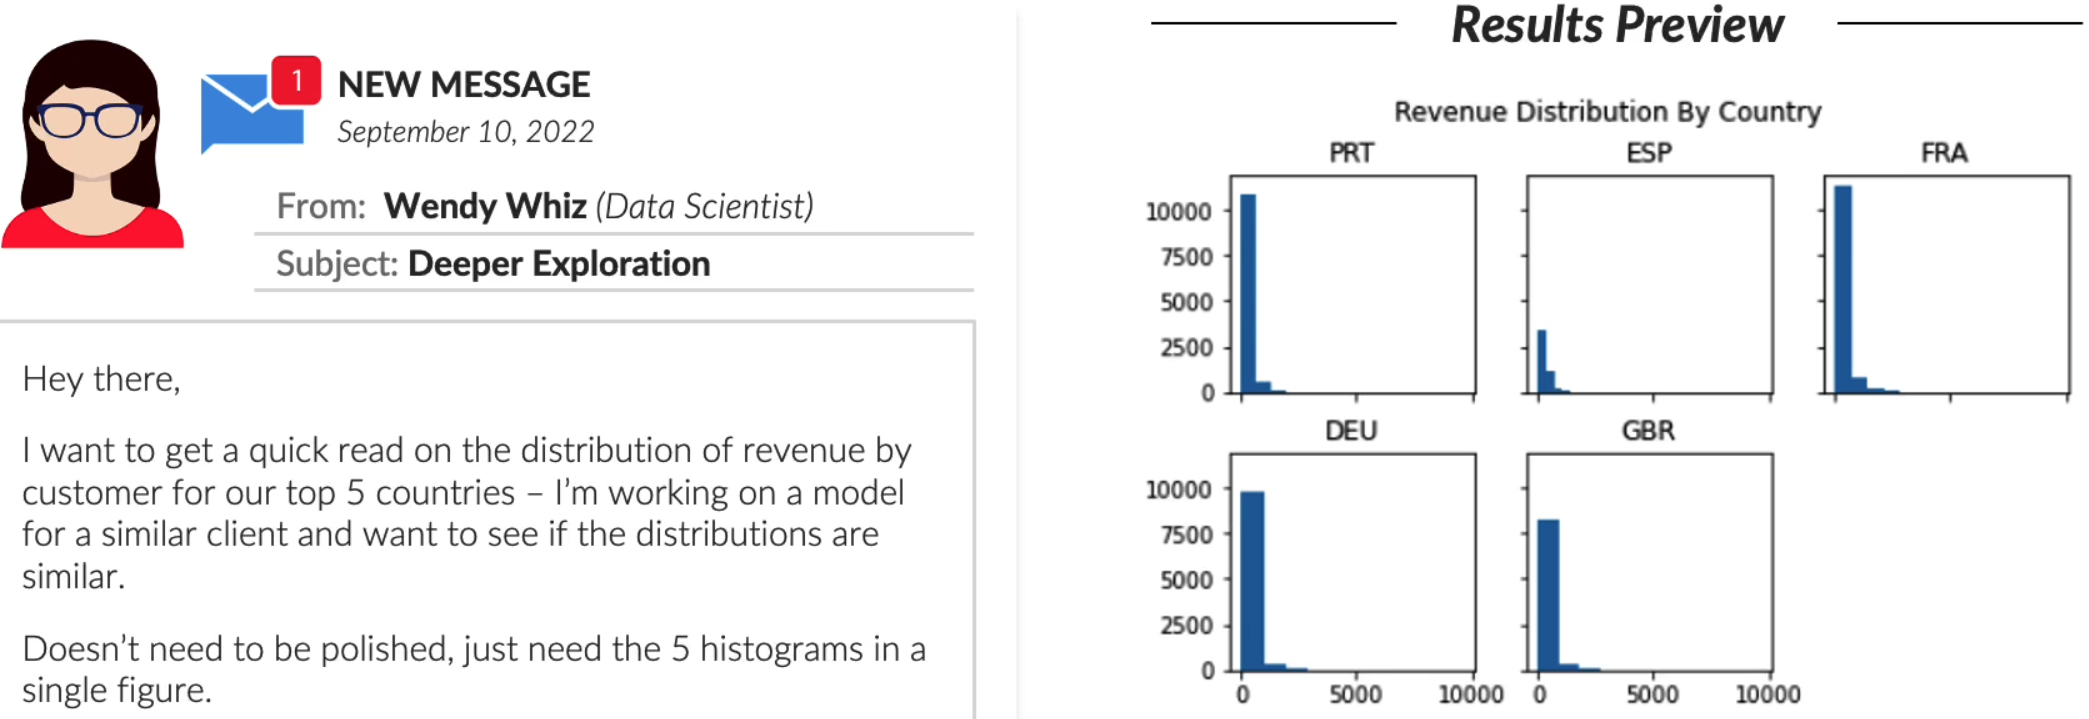
>
>---
>
>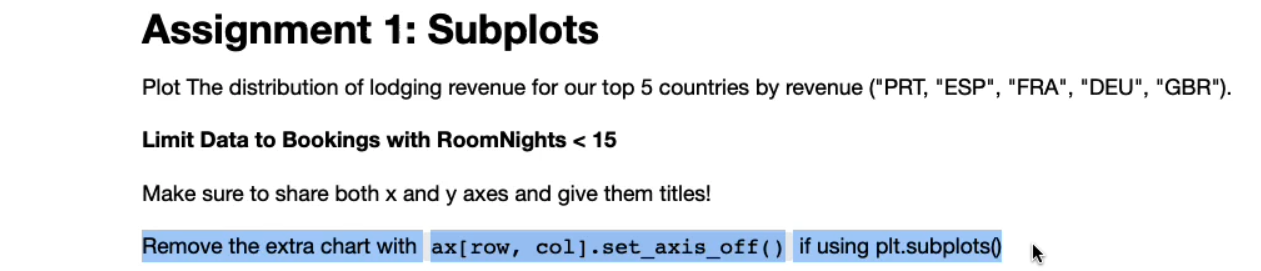
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_excel('../Data/HotelCustomersDataset.xlsx')
df_raw.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---

In [3]:
df = df_raw.loc[:, ['Nationality', 'LodgingRevenue', 'OtherRevenue', 'RoomNights']]
sel_nation = ['PRT', 'ESP', 'FRA', 'DEU', 'GBR']
df = df.query("Nationality in @sel_nation and RoomNights < 15")
df

,Nationality,LodgingRevenue,OtherRevenue,RoomNights
0,PRT,371.0,105.3,5
1,PRT,280.0,53.0,5
2,DEU,0.0,0.0,0
3,FRA,240.0,60.0,5
4,FRA,0.0,0.0,0
...,...,...,...,...
83579,PRT,0.0,0.0,0
83580,DEU,176.0,147.0,2
83581,DEU,0.0,0.0,0
83582,FRA,143.0,2.0,1


In [4]:
df.Nationality.unique()

array(['PRT', 'DEU', 'FRA', 'ESP', 'GBR'], dtype=object)

In [5]:
df.RoomNights.unique()

array([ 5,  0,  4,  3,  2, 14,  1,  6, 11,  7,  8, 10,  9, 12, 13])

<br><br>

---

Since our Dataset now is ready and filtered. We can start the plotting task...

- First we need to understand the structure of the Axes Object for a 2x3 plot

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]


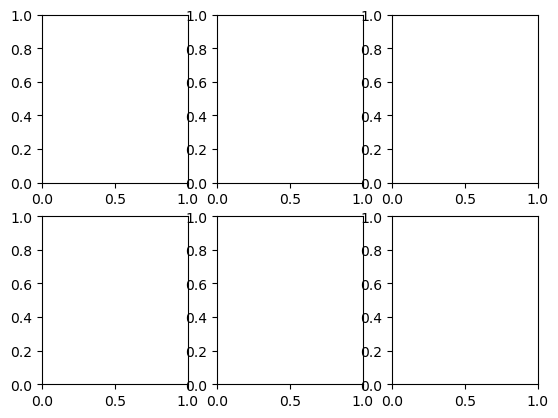

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=3)

print(axes)

The Axes Object Structure is a 2D array. There for we need to consider that structure if we want to automate the plotting...

<br><br>


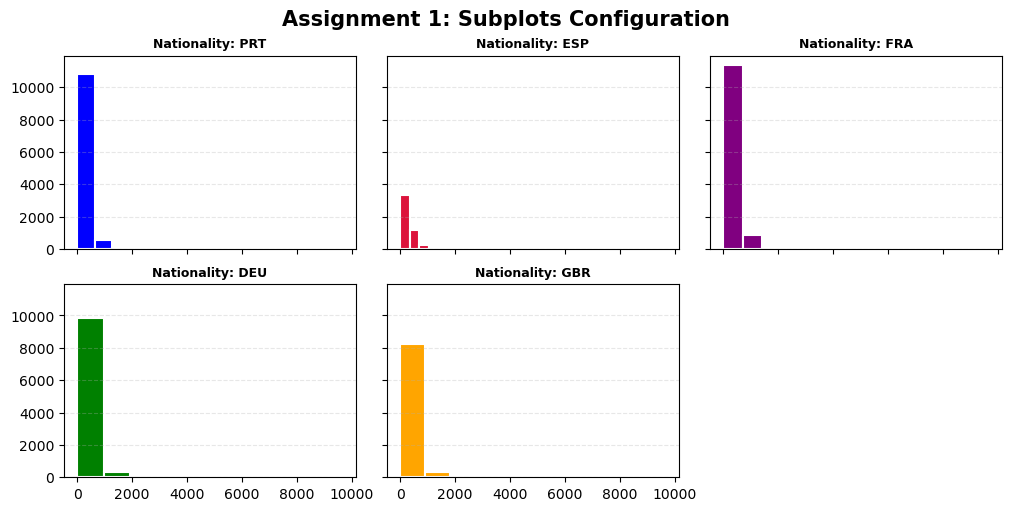

In [12]:
colorss = [['blue', 'crimson', 'purple'], ['green', 'orange', None]]
nationss = [['PRT', 'ESP', 'FRA'], ['DEU', 'GBR', None]]
# ---------------------------------------------------------------------------------
fig, axess = plt.subplots(figsize=(10, 5), constrained_layout=True,
                          nrows=2, ncols=3, sharex='all', sharey='all')
# ---------------------------------------------------------------------------------
counter = 0
for axes, nations, colors  in zip(axess, nationss, colorss):
    for ax, nat, c in zip(axes, nations, colors):
        if counter != 5:
            df_plot = df[df['Nationality']== nat]['LodgingRevenue']
            ax.hist(df_plot, edgecolor='white', label=f'{nat}', linewidth=1.5, color=c)
            ax.set_title(f'Nationality: {nat}', fontsize=9, fontweight='bold')
            ax.grid(axis='y', ls='--', alpha=0.3)
            counter += 1
        else:
            ax.set_axis_off()
# ---------------------------------------------------------------------------------
fig.suptitle('Assignment 1: Subplots Configuration', fontsize=15, fontweight='bold')
plt.show()

<br><br>

---

## SOLUTION No. 2

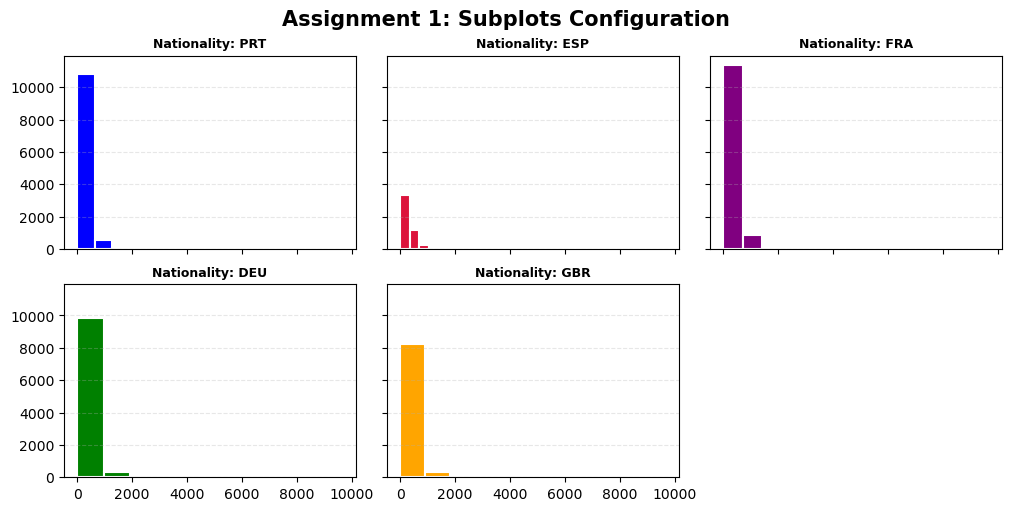

In [14]:
nations = ['PRT', 'ESP', 'FRA', 'DEU', 'GBR']
colors = ['blue', 'crimson', 'purple', 'green', 'orange']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5),
                         constrained_layout=True, sharex=True, sharey=True)

# I use "axex.flat" to avoid setting 2D format lists
for ax, nat, c in zip(axes.flat, nations, colors):
    data = df.loc[df['Nationality'] == nat, 'LodgingRevenue']
    ax.hist(data, edgecolor='white', linewidth=1.5, color=c)
    ax.set_title(f'Nationality: {nat}', fontsize=9, fontweight='bold')
    ax.grid(axis='y', ls='--', alpha=0.3)

# Turn off unused subplots
for ax in axes.flat[len(nations):]:
    ax.set_axis_off()

fig.suptitle('Assignment 1: Subplots Configuration', fontsize=15, fontweight='bold')
plt.show()